In [30]:
import numpy as np
import bacco
import matplotlib.pyplot as plt

In [5]:
import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

In [38]:
## Load the Zooms
sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

name_list = ['fiducial', 'bestfit_run']

snap = 264
zoom = {}

for i in range(len(name_list)):
    base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/"+name_list[i]+"/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)

# Load the Halo Selection
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

2026-06-16 21:26:11,374 bacco.sims : Initialising simulation Default
2026-06-16 21:26:11,375 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-06-16 21:26:11,459 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-06-16 21:26:11,501 bacco.sims : ...done in 0.127 s
2026-06-16 21:26:11,502 bacco.sims : Initialising simulation Default
2026-06-16 21:26:11,503 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/bestfit_run/hydro_output/snapdir_264/snapshot_264
2026-06-16 21:26:11,506 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/bestfit_run/hydro_output/snapdir_264/snapshot_264
2026-06-16 21:26:11,511 bacco.sims : ...done in 0.00864 s


In [39]:
# Perform the cross-match with MTNG halos
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264, name=name_list[i])

2026-06-16 21:26:13,257 bacco.sims : Initialising simulation Default
2026-06-16 21:26:13,258 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-06-16 21:26:13,263 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-06-16 21:26:13,270 bacco.sims : ...done in 0.0129 s
2026-06-16 21:26:13,275 bacco.sims : Reading 98233510 items for GroupPos


2026-06-16 21:26:16,769 bacco.sims : Reading 90246895 items for SubhaloPos
2026-06-16 21:26:20,164 bacco.sims : Reading 139582 items for GroupPos
2026-06-16 21:26:20,240 bacco.sims : Reading 139582 items for Group_M_Mean200
2026-06-16 21:26:20,254 bacco.sims : Reading 98233510 items for Group_M_Mean200
2026-06-16 21:26:21,621 bacco.sims : Reading 139582 items for GroupVel
2026-06-16 21:26:21,640 bacco.sims : Reading 98233510 items for GroupVel
/cosmos_storage/home/fgmaion/MTNG-resims/src/utils.py:1410: RuntimeWarning: divide by zero encountered in divide
  d_m = np.abs((1 - m1[..., np.newaxis]/m2) / 0.2)


In [40]:
# Load MTNG and get the fraction of halos to do the upweighting
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]


2026-06-16 21:26:24,061 bacco.sims : Initialising simulation Default
2026-06-16 21:26:24,062 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-06-16 21:26:24,064 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-06-16 21:26:24,070 bacco.sims : ...done in 0.00868 s
2026-06-16 21:26:24,075 bacco.sims : Reading 98233510 items for Group_M_Mean200


/tmp/ipykernel_30000/1675892996.py:4: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])


In [43]:
sub_indices = {}

for i in range(len(name_list)):
    sub_indices[name_list[i]] = np.empty((0,), dtype=int)

    first = zoom[name_list[i]].fof['halo_firstsub']
    nsubs = zoom[name_list[i]].fof['halo_nsubs']

    sub_indices[name_list[i]] = np.empty((0,), dtype=int)
    for j in range(len(zoom_sel[name_list[i]]['sel'])):
        ihalo = zoom_sel[name_list[i]]['sel'][j,0,0]
        _sub_indices = np.arange(first[ihalo], first[ihalo] + nsubs[ihalo])
        sub_indices[name_list[i]] = np.append(sub_indices[name_list[i]], _sub_indices)

2026-06-16 21:30:59,958 bacco.sims : Reading 139582 items for halo_firstsub
2026-06-16 21:30:59,985 bacco.sims : Reading 139582 items for GroupNsubs


In [44]:
mstar = {}

for i in range(len(name_list)):
    mstar[name_list[i]] = zoom_split[name_list[i]].get_mstar_30kpc_general_vec(zoom[name_list[i]], sub_indices[name_list[i]], z=0)

2026-06-16 21:31:07,068 bacco.sims : Reading 74777 items for Subhalo/SubhaloOffset


2026-06-16 21:31:07,332 bacco.sims : Reading 74777 items for SubhaloLenType
2026-06-16 21:31:07,424 bacco.sims : Read data for 796017/6141061 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-06-16 21:31:07,998 bacco.sims : Read data for 796017/6141061 particles...
2026-06-16 21:31:08,046 bacco.sims : Read data for 742440/6141061 particles...
2026-06-16 21:31:08,533 bacco.sims : Read data for 742440/6141061 particles...
2026-06-16 21:31:08,551 bacco.sims : Read data for 770918/6141061 particles...
2026-06-16 21:31:09,036 bacco.sims : Read data for 770918/6141061 particles...
2026-06-16 21:31:09,072 bacco.sims : Read data for 792109/6141061 particles...
2026-06-16 21:31:09,610 bacco.sims : Read data for 792109/6141061 particles...
2026-06-16 21:31:09,681 bacco.sims : Read data for 736460/6141061 particles...
2026-06-16 21:31:10,252 bacco.sims : Read data for 736460/6141061 particles...
2026-06-16 21:31:10,305 bacco.sims : Read data for 757977/6141061 particles...
2026-06-16 21:31:10,873 bacco.sims : Read data for 757977/6141061 particles...
2026-06-16 21:31:10,925 bacco.sims : Read data for 779883/6141061 particles...
2026-06-16 21:31:11,547 bacco.sims : Read data for 7

/cosmos_storage/simulations/TNG_Family/MN5_resims/bestfit_run/hydro_output/snapdir_264/snapshot_264.0.hdf5


2026-06-16 21:31:13,515 bacco.sims : Read data for 966989/7489825 particles...
2026-06-16 21:31:13,517 bacco.sims : Read data for 940365/7489825 particles...
2026-06-16 21:31:13,656 bacco.sims : Read data for 940365/7489825 particles...
2026-06-16 21:31:13,658 bacco.sims : Read data for 912342/7489825 particles...
2026-06-16 21:31:13,792 bacco.sims : Read data for 912342/7489825 particles...
2026-06-16 21:31:13,794 bacco.sims : Read data for 889151/7489825 particles...
2026-06-16 21:31:13,927 bacco.sims : Read data for 889151/7489825 particles...
2026-06-16 21:31:13,929 bacco.sims : Read data for 926105/7489825 particles...
2026-06-16 21:31:14,066 bacco.sims : Read data for 926105/7489825 particles...
2026-06-16 21:31:14,068 bacco.sims : Read data for 946030/7489825 particles...
2026-06-16 21:31:14,207 bacco.sims : Read data for 946030/7489825 particles...
2026-06-16 21:31:14,210 bacco.sims : Read data for 931222/7489825 particles...
2026-06-16 21:31:14,347 bacco.sims : Read data for 9

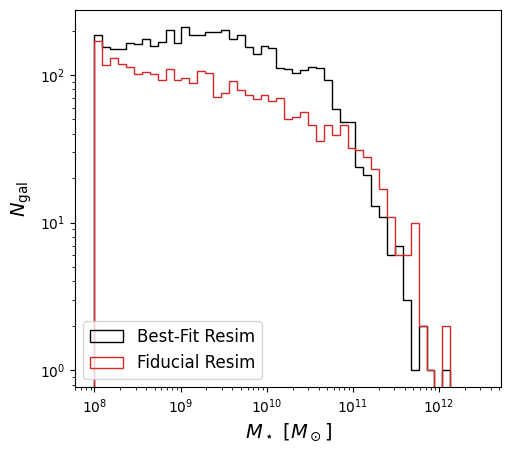

In [49]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))

ax.set_xscale('log')
ax.hist(1e10 * mstar['bestfit_run'], bins=np.logspace(8, 12.5, 50), density=False, histtype='step', color='k', log=True, label='Best-Fit Resim');
ax.hist(1e10 * mstar['fiducial'], bins=np.logspace(8, 12.5, 50), density=False, histtype='step', color='C3', log=True, label='Fiducial Resim');

ax.set_xlabel(r"$M_\star$ [$M_\odot$]", fontsize=14)
ax.set_ylabel(r"$N_\mathrm{gal}$", fontsize=14)

ax.legend(fontsize=12, loc='lower left')

In [58]:
zoom_smf = {}
for i in range(len(name_list)):
    zoom_smf[name_list[i]] = zoom_split[name_list[i]].halo_smf_draws(sel_mask=zoom_sel[name_list[i]], nbins=12, draws=1, m_30kpc=True)

zoom_fgas = {}
for i in range(len(name_list)):
    zoom_fgas[name_list[i]] = zoom_split[name_list[i]].halo_gas_frac_v2(sel_mask=zoom_sel[name_list[i]], nbins=12, draws=1)

In [59]:
zoom_smf['bestfit_run']['mstar']

{0: array([1.48628112e+09, 3.00069112e+09, 6.24057371e+09, 1.26634872e+10,
        2.77961183e+10, 5.17207326e+10, 1.07328521e+11, 2.19827510e+11,
        4.45748181e+11, 8.12785007e+11])}

In [61]:
gsmf = np.loadtxt('/cosmos_storage/home/fgmaion/MTNG-resims/data/GAMA_SDSS_stitched_GSMF_h0p6774.csv',
                  delimiter=',', comments='#', skiprows=33,
                  usecols=(0, 1, 2))

In [71]:
def mean_std_without_zeros(array):
    ndraws, nbins = array.shape
    mean_values = []
    std_values = []

    for i in range(nbins):
        non_zero_values = array[:, i][array[:, i] != 0]
        mean_values.append(np.mean(non_zero_values))
        std_values.append(np.std(non_zero_values))

    return np.array(mean_values), np.array(std_values)

In [81]:
smf_draws = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/smf/smf_draws/smf_draws100_nbins10.npy", allow_pickle=True).item()
mean_smf, err_smf = mean_std_without_zeros(smf_draws['ens_smf'])
mstar_smf, _ = mean_std_without_zeros(smf_draws['mstar'])
err_log_smf = err_smf / mean_smf / np.log(10)

Text(0, 0.5, '$\\log_{10} \\phi(M_\\star)$ [$\\mathrm{Mpc}^{-3}\\,\\mathrm{dex}^{-1}$]')

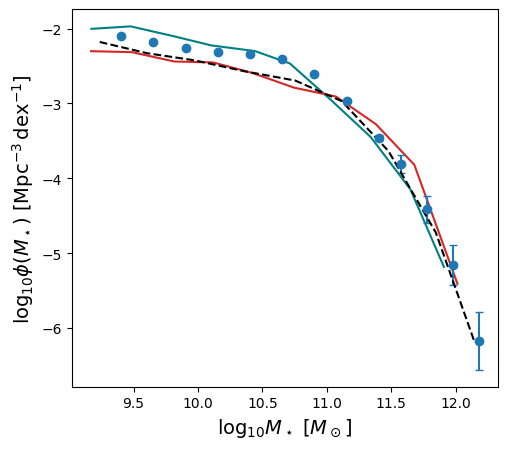

In [82]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))

ax.plot(np.log10(zoom_smf['bestfit_run']['mstar'][0]), np.log10(zoom_smf['bestfit_run']['smf'][0]), color='teal', label='Best-Fit Resim')
ax.plot(np.log10(zoom_smf['fiducial']['mstar'][0]), np.log10(zoom_smf['fiducial']['smf'][0]), color='C3', label='Fiducial Resim')
ax.errorbar(gsmf[:,0], gsmf[:,1], marker='o', yerr=gsmf[:,2], color='C0', ls='', label='GAMA+SDSS', capsize=3)
ax.plot(np.log10(mstar_smf), np.log10(mean_smf), ls='--', color='k')

ax.set_xlabel(r"$\log_{10} M_\star$ [$M_\odot$]", fontsize=14)
ax.set_ylabel(r"$\log_{10} \phi(M_\star)$ [$\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}$]", fontsize=14)